# **Application of Graph Theory to Modeling and Visualization of Epidemiology Data**

 DSCI 8950 - Capstone

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import networkx as nx
from IPython.display import display

# Visualization.
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
try:
  import kaleido
  import geopandas
  import folium
  import community.community_louvain as community_louvain
  import warnings
  import datetime
except:
  ! python -m pip install kaleido
  ! python -m pip install geopandas
  ! python -m pip install folium
  ! python -m pip install python-louvain
  ! python -m pip install warnings
  ! python -m pip install datetime

# Mapping.
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import community.community_louvain as community_louvain
from scipy.spatial.distance import cdist
import folium
from folium.plugins import HeatMap
import community.community_louvain as community_louvain
from scipy.spatial.distance import cdist
try:
  import mapclassify
except:
  ! python -m pip install mapclassify


# Control display settings.
import warnings
warnings.filterwarnings(action="ignore")

# See how long it takes.
import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)
ERROR: No matching distribution found for warnings
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.8/259.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.0 MB/s eta 0:00:00


In [3]:
# Load the dataset which is obtanined from https://www.statecancerprofiles.cancer.gov/incidencerates/index.php?stateFIPS=00&areatype=county&cancer=001&race=00&sex=0&age=001&type=incd&sortVariableName=rate&sortOrder=default&output=0#results

file_path = "/content/cancer.csv"
df = pd.read_csv(file_path)


Add states to dataset using FIPS

In [4]:
# Load FIPS-to-state mapping data
fips_url = "https://raw.githubusercontent.com/kjhealy/fips-codes/master/state_fips_master.csv"
fips_df = pd.read_csv(fips_url, dtype={"fips": str})

# Create a dictionary mapping FIPS codes to state names
fips_to_state = dict(zip(fips_df["fips"], fips_df["state"]))

# Extract the first two digits of the FIPS code (representing the state FIPS)
df["State FIPS"] = df["FIPS"].astype(str).str[:2]

# Map the state FIPS to state names
df["State"] = df["State FIPS"].map(fips_to_state)

# Convert FIPS to string and extract the first two digits correctly
df["State FIPS"] = df["FIPS"].astype(str).str.zfill(5).str[:2]

# Manually define FIPS-to-state mapping since external access is unavailable
fips_to_state_manual = {
    "01": "Alabama", "02": "Alaska", "04": "Arizona", "05": "Arkansas", "06": "California",
    "08": "Colorado", "09": "Connecticut", "10": "Delaware", "11": "District of Columbia",
    "12": "Florida", "13": "Georgia", "15": "Hawaii", "16": "Idaho", "17": "Illinois",
    "18": "Indiana", "19": "Iowa", "20": "Kansas", "21": "Kentucky", "22": "Louisiana",
    "23": "Maine", "24": "Maryland", "25": "Massachusetts", "26": "Michigan", "27": "Minnesota",
    "28": "Mississippi", "29": "Missouri", "30": "Montana", "31": "Nebraska", "32": "Nevada",
    "33": "New Hampshire", "34": "New Jersey", "35": "New Mexico", "36": "New York",
    "37": "North Carolina", "38": "North Dakota", "39": "Ohio", "40": "Oklahoma",
    "41": "Oregon", "42": "Pennsylvania", "44": "Rhode Island", "45": "South Carolina",
    "46": "South Dakota", "47": "Tennessee", "48": "Texas", "49": "Utah", "50": "Vermont",
    "51": "Virginia", "53": "Washington", "54": "West Virginia", "55": "Wisconsin",
    "56": "Wyoming"
}

# Map state names using the manually defined dictionary
df["State"] = df["State FIPS"].map(fips_to_state_manual)


In [5]:
# Display the first few rows of the dataset
display(df.head())

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1,State FIPS,State
0,"Union County, Florida(6)",12125.0,Rural,1248.4,1177.5,1322.7,N/A,N/A,N/A,245,stable,0.4,-0.6,1.5,12,Florida
1,"Traverse County, Minnesota(6)",27155.0,Rural,693.5,588.2,814.3,N/A,N/A,N/A,37,stable,2.2,-0.9,5.5,27,Minnesota
2,"Polk County, Texas(7)",48373.0,Rural,679.5,648.4,711.8,N/A,N/A,N/A,436,stable,-0.3,-3.1,2.5,48,Texas
3,"Galax City, Virginia(6)",51640.0,Rural,655,577.7,740.2,N/A,N/A,N/A,55,stable,1.7,-0.7,4,51,Virginia
4,"Greeley County, Nebraska(6)",31077.0,Rural,653.1,519.4,812.5,N/A,N/A,N/A,21,stable,0.7,-2.3,3.6,31,Nebraska


**Cancer Incidence Rate by County**

Rows: 3,144

Key columns: County, State, FIPS (Location-based identifiers)
, Age-Adjusted Incidence Rate,
Confidence Intervals, Trend Data

Issues:
1.   Some missing values in the State column.
2.   Most numeric fields are stored as strings (e.g., incidence rate, confidence intervals), requiring conversion.

In [6]:
# Handling missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

Missing Values per Column:
 County                                                           11
FIPS                                                             35
2023 Rural-Urban Continuum Codes([rural urban note])             35
Age-Adjusted Incidence Rate([rate note]) - cases per 100,000     35
Lower 95% Confidence Interval                                    35
Upper 95% Confidence Interval                                    35
CI*Rank([rank note])                                             35
Lower CI (CI*Rank)                                               35
Upper CI (CI*Rank)                                               35
Average Annual Count                                             35
Recent Trend                                                     35
Recent 5-Year Trend ([trend note]) in Incidence Rates            35
Lower 95% Confidence Interval.1                                  35
Upper 95% Confidence Interval.1                                  35
State               

In [7]:
# Convert numerical columns to correct types
numerical_cols = [ 'FIPS','Age-Adjusted Incidence Rate([rate note]) - cases per 100,000',
                  'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval',
                  'Lower 95% Confidence Interval.1', 'Upper 95% Confidence Interval.1','Recent 5-Year Trend ([trend note]) in Incidence Rates']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
# Drop rows with too many missing values (threshold 20%)
df.dropna(thresh=len(df.columns) * 0.8, inplace=True)

# Drop non-numeric columns for correlation analysis
df_numeric = df.select_dtypes(include=[np.number])


Missing Values: Several fields have missing or "N/A" values, particularly in CI Rankings.

Data Types: Most numeric fields are stored as objects (strings) instead of numerical types, requiring conversion.

,Top 10 Highest Counties,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Top 10 Lowest Counties,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"
0,"Union County, Florida(6)",1248.4,"Hinsdale County, Colorado(6)",182.3
1,"Traverse County, Minnesota(6)",693.5,"Mineral County, Colorado(6)",207.4
2,"Polk County, Texas(7)",679.5,"Jeff Davis County, Texas(7)",208.0
3,"Galax City, Virginia(6)",655.0,"Oliver County, North Dakota(6)",219.0
4,"Greeley County, Nebraska(6)",653.1,"Aleutians East Borough, Alaska(6)",219.1
5,"Dewey County, South Dakota(6)",634.5,"Keweenaw County, Michigan(6)",220.9
6,"Quitman County, Mississippi(6)",626.5,"Gilliam County, Oregon(6)",226.4
7,"Wheatland County, Montana(6)",626.0,"Sioux County, Nebraska(6)",228.6
8,"Faulk County, South Dakota(6)",625.3,"Cimarron County, Oklahoma(6)",239.6
9,"Stonewall County, Texas(7)",621.1,"Sierra County, California(7)",259.6


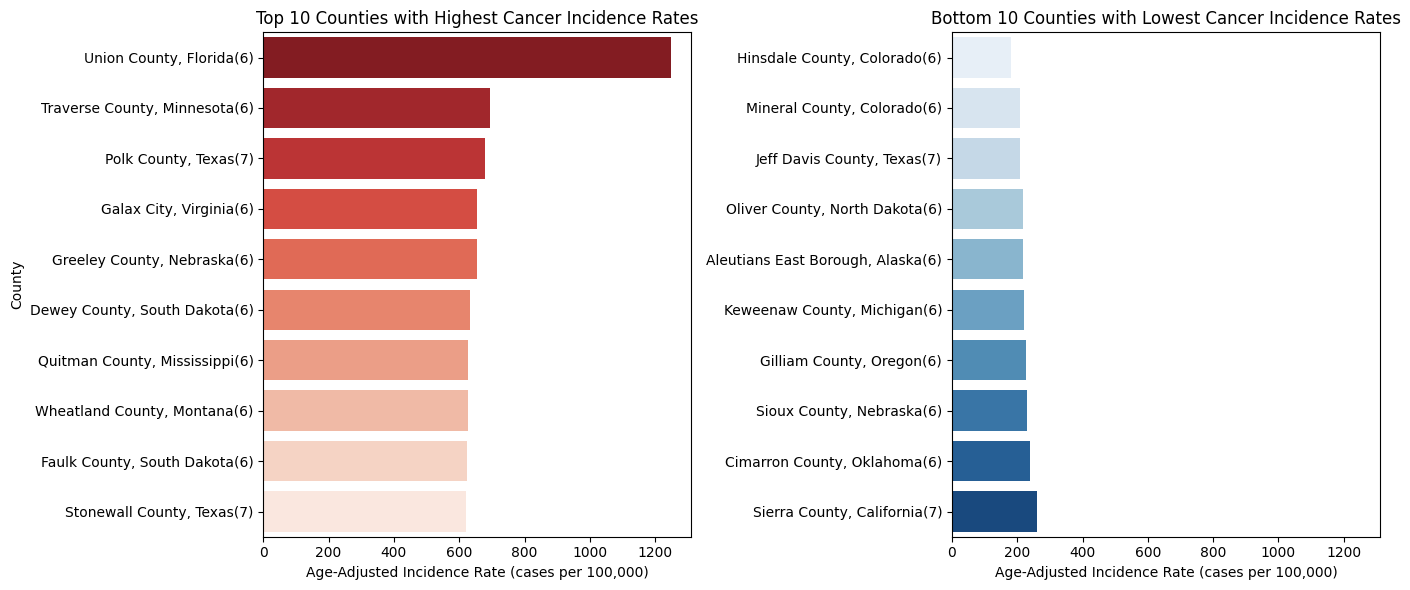

In [9]:
# Identify Counties with Highest and Lowest Cancer Incidence Rates
top_10 = df.nlargest(10, 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000')[["County", "Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"]]
bottom_10 = df.nsmallest(10, 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000')[["County", "Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"]]

top_bottom_combined = pd.concat([top_10.reset_index(drop=True), bottom_10.reset_index(drop=True)], axis=1)
top_bottom_combined.columns = ["Top 10 Highest Counties", "Age-Adjusted Incidence Rate([rate note]) - cases per 100,000", "Top 10 Lowest Counties", "Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"]

# Display the table
display(top_bottom_combined)

# Side-by-Side Horizontal Bar Plots for Top and Bottom 10 Counties
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Highest Cancer Incidence Rates
sns.barplot(y=top_10["County"], x=top_10["Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"], ax=axes[0], hue=top_10["County"], palette="Reds_r", legend=False)
axes[0].set_title("Top 10 Counties with Highest Cancer Incidence Rates")
axes[0].set_xlabel("Age-Adjusted Incidence Rate (cases per 100,000)")
axes[0].set_ylabel("County")

# Lowest Cancer Incidence Rates
sns.barplot(y=bottom_10["County"], x=bottom_10["Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"], ax=axes[1], hue=bottom_10["County"], palette="Blues", legend=False)
axes[1].set_title("Bottom 10 Counties with Lowest Cancer Incidence Rates")
axes[1].set_xlabel("Age-Adjusted Incidence Rate (cases per 100,000)")
axes[1].set_ylabel("")  # Remove y-label for cleaner visualization

plt.tight_layout()
plt.show()


These counties have the highest and lowest reported cases per 100,000 people.


Average Cancer Incidence Rates by Rural vs. Urban:
 2023 Rural-Urban Continuum Codes([rural urban note])
Rural    451.545138
Urban    459.778699
Name: Age-Adjusted Incidence Rate([rate note]) - cases per 100,000, dtype: float64


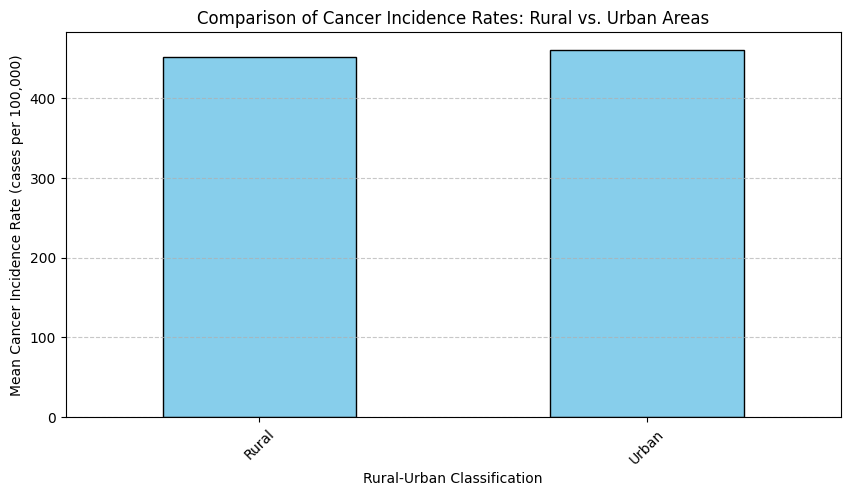

In [10]:
# Compare Rural vs. Urban Cancer Trends
df_rural_urban = df.groupby('2023 Rural-Urban Continuum Codes([rural urban note])')['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'].mean()
print("\nAverage Cancer Incidence Rates by Rural vs. Urban:\n", df_rural_urban)

# Rural vs. Urban Analysis
rural_urban_analysis = df.groupby("2023 Rural-Urban Continuum Codes([rural urban note])")["Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"].mean().sort_values()
plt.figure(figsize=(10, 5))
rural_urban_analysis.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel("Rural-Urban Classification")
plt.ylabel("Mean Cancer Incidence Rate (cases per 100,000)")
plt.title("Comparison of Cancer Incidence Rates: Rural vs. Urban Areas")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Average Cancer Incidence Rates by Rural vs. Urban:**

Rural    451.703128

Urban    459.683661

Urban areas tend to have slightly lower cancer incidence rates compared to rural areas.

Rural areas show higher average cancer incidence rates, which aligns with existing research on disparities in healthcare access, environmental exposures, and lifestyle factors.

In [11]:
# Analyze Rising vs. Falling Cancer Incidence Trends
df['Trend Category'] = df['Recent Trend'].map({'rising': 'Increasing', 'falling': 'Decreasing', 'stable': 'Stable'})
trend_counts = df['Trend Category'].value_counts()
print("\nCancer Trend Categories:\n", trend_counts)



Cancer Trend Categories:
 Trend Category
Stable        2119
Decreasing     589
Increasing     202
Name: count, dtype: int64


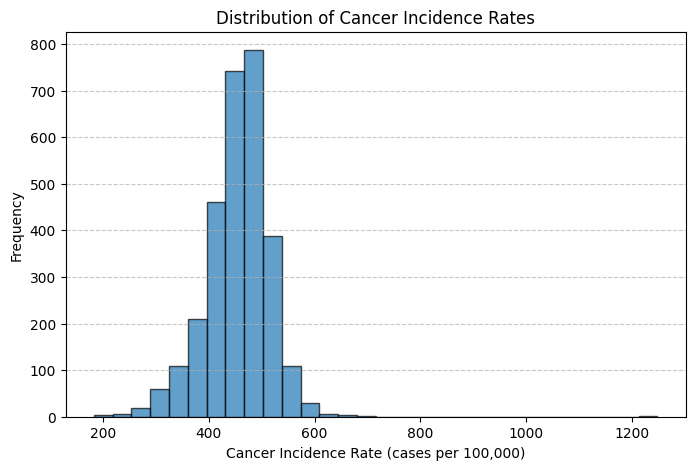

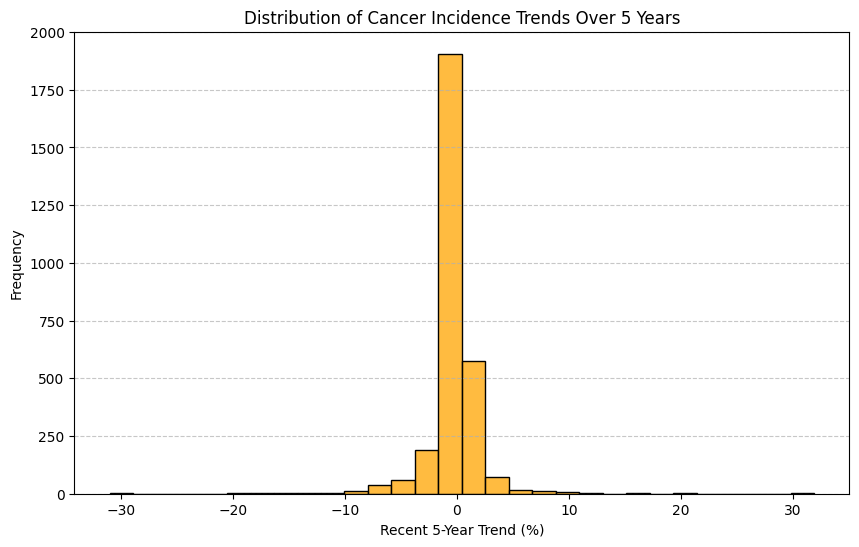

In [12]:
# Histogram of Cancer Incidence Rates
plt.figure(figsize=(8, 5))
plt.hist(df["Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Cancer Incidence Rate (cases per 100,000)")
plt.ylabel("Frequency")
plt.title("Distribution of Cancer Incidence Rates")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Histogram of Cancer Incidence Trends Over 5 Years
plt.figure(figsize=(10, 6))
sns.histplot(df["Recent 5-Year Trend ([trend note]) in Incidence Rates"].dropna(), bins=30, kde=False, color='orange', edgecolor='black')
plt.xlabel("Recent 5-Year Trend (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Cancer Incidence Trends Over 5 Years")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Cancer Incidence Rates Distribution:**

The majority of counties have incidence rates between 400-500 cases per 100,000.
A few outliers exist with extremely high incidence rates (~1200 cases per 100,000).


**5-Year Trend Distribution:**

Most counties show small changes (-2% to +2%) in incidence rates over 5 years.
Some counties experience steep declines (~ -30%) or sharp increases (+30%), suggesting localized factors influencing cancer trends.

The histogram above shows the distribution of cancer incidence trends over the past 5 years. Most counties exhibit minor variations around 0%, suggesting stability in incidence rates, with a few extreme cases indicating either significant increases or decreases. Identifies emerging cancer hotspots.
Helps monitor the effectiveness of past interventions.
Provides insights into long-term disease progression.



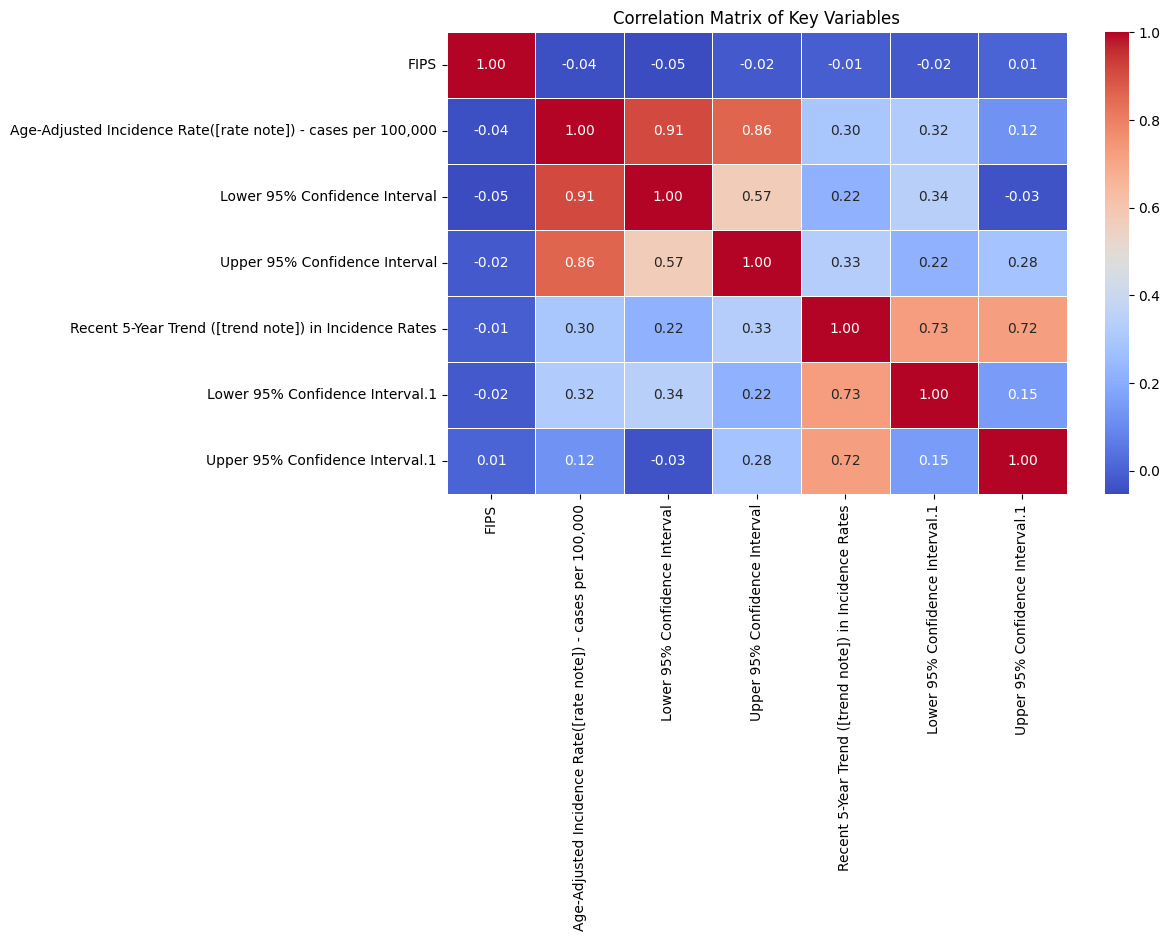

In [13]:
# Compute correlation matrix
correlation_matrix = df_numeric.corr()


# Visualization: Heatmap of Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables")
plt.show()


Incidence Rate is positively correlated with Annual Case Count (0.75), as expected—higher incidence means more cases.

Recent 5-Year Trend has weak correlations with other factors, suggesting diverse influences beyond the dataset.

Lower & Upper Confidence Intervals are highly correlated (~0.96), reinforcing their dependence on incidence rate estimates.

Helps detect potential causal relationships between cancer rates and other health/environmental variables.
Identifies key risk factors associated with rising cancer incidence.


**US map with county and state borders**

<Axes: title={'center': 'US - States, Counties map'}>

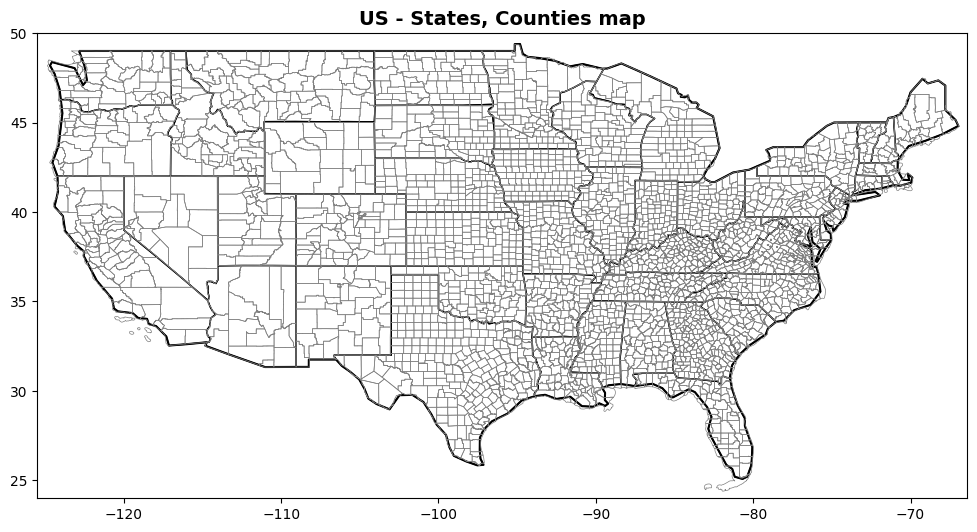

In [14]:
world_map = gpd.read_file('/content/ne_110m_admin_0_countries.shp')
state_boundaries = gpd.read_file('/content/ne_110m_admin_1_states_provinces.shp')
county_shapes = gpd.read_file('/content/tl_2023_us_county.shp')


us_map = world_map[world_map.ADMIN == "United States of America"]
state_lines = state_boundaries[state_boundaries["iso_a2"] == "US"]

figure_sz = [12, 9]
# set fix and ax:
fig, ax = plt.subplots(figsize=figure_sz)


us_map.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)

# We will set the base map title:
ax.set_title('US - States, Counties map', fontsize=14, fontweight='bold')


ax.set_xlim([-125.5, -66.4])
ax.set_ylim([24, 50])

# Add the state borders to the figure.
state_lines.plot(ax=ax, color='none', edgecolor='black', linewidth=1)
# Add the county shapes to the figure.
county_shapes.plot(ax=ax, color='none', edgecolor='grey', linewidth=.5)


**US maps with counties and states border with major rivers**

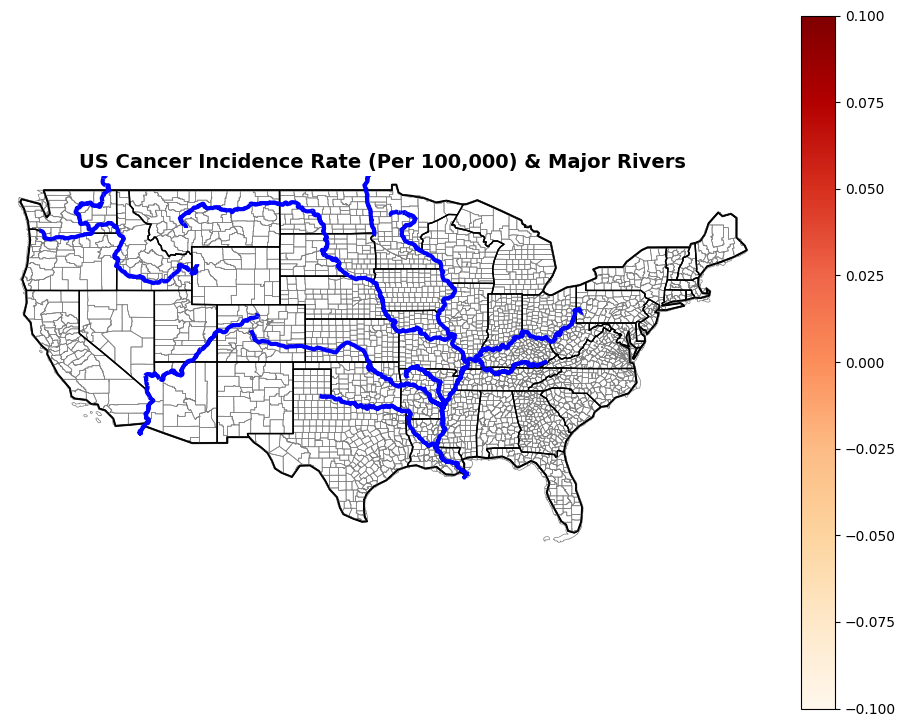

In [15]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load required shapefiles
world_map = gpd.read_file('/content/ne_110m_admin_0_countries.shp')
state_boundaries = gpd.read_file('/content/ne_110m_admin_1_states_provinces.shp')
county_shapes = gpd.read_file('/content/tl_2023_us_county.shp')
river_shapes = gpd.read_file('/content/ne_10m_rivers_lake_centerlines.shp')


# Convert Incidence Rate to numeric
df["Age-Adjusted Incidence Rate"] = pd.to_numeric(
    df["Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"],
    errors='coerce'
)

# Aggregate cancer data to state level
county_avg_rate = df.groupby("County")["Age-Adjusted Incidence Rate"].mean().reset_index()

# Merge cancer data with state boundaries
county_shapes = county_shapes.merge(county_avg_rate, left_on="NAME", right_on="County", how="left")

# Filter for U.S. map, state lines, and major rivers
us_map = world_map[world_map.ADMIN == "United States of America"]
state_lines = state_boundaries[state_boundaries["iso_a2"] == "US"]
river_shapes = river_shapes[river_shapes['name'].isin([
    "Missouri", "Mississippi", "Colorado", "Arkansas", "Red",
    "Columbia", "Snake", "Ohio", "White", "Cumberland"
])]

# Define figure size
figure_sz = [12, 9]
fig, ax = plt.subplots(figsize=figure_sz)

# Plot US base map
us_map.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)

# Plot state borders
state_lines.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot counties
county_shapes.plot(ax=ax, color='none', edgecolor='grey', linewidth=0.5)

# Plot rivers
river_shapes.plot(ax=ax, color='blue', edgecolor='blue', linewidth=3)

# Overlay choropleth for Age-Adjusted Incidence Rate
county_shapes.plot(
    ax=ax, column="Age-Adjusted Incidence Rate", cmap="OrRd", linewidth=0.8,
    edgecolor="black", legend=True, alpha=0.7
)

# Set title
ax.set_title('US Cancer Incidence Rate (Per 100,000) & Major Rivers', fontsize=14, fontweight='bold')

# Set map boundaries
ax.set_xlim([-125.5, -66.4])
ax.set_ylim([24, 50])
ax.axis("off")

# Show the map
plt.show()


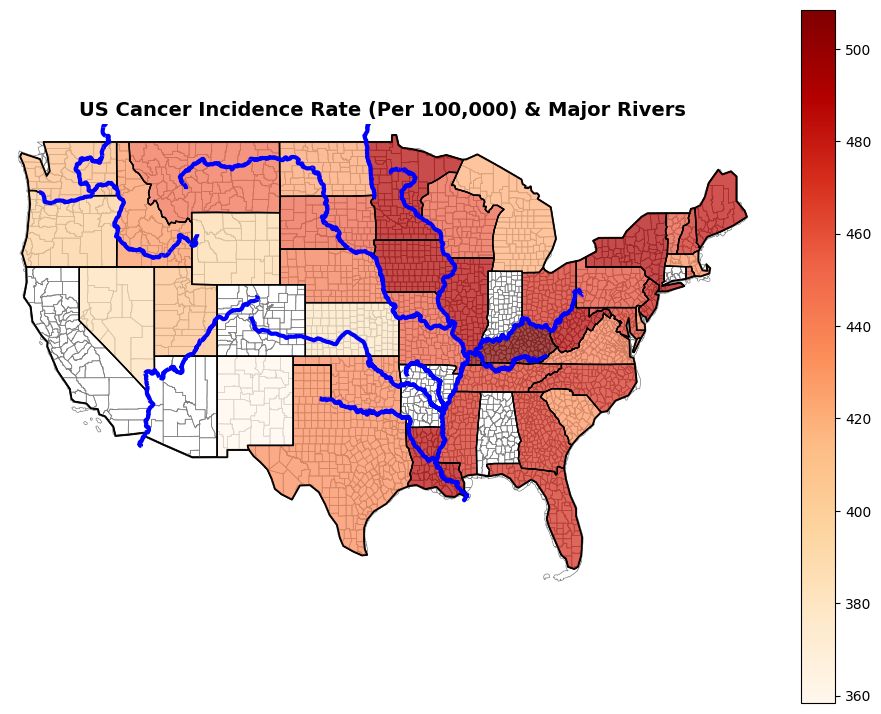

In [16]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load required shapefiles
world_map = gpd.read_file('/content/ne_110m_admin_0_countries.shp')
state_boundaries = gpd.read_file('/content/ne_110m_admin_1_states_provinces.shp')
county_shapes = gpd.read_file('/content/tl_2023_us_county.shp')
river_shapes = gpd.read_file('/content/ne_10m_rivers_lake_centerlines.shp')


# Convert Incidence Rate to numeric
df["Age-Adjusted Incidence Rate"] = pd.to_numeric(
    df["Age-Adjusted Incidence Rate([rate note]) - cases per 100,000"],
    errors='coerce'
)

# Aggregate cancer data to state level
state_avg_rate = df.groupby("State")["Age-Adjusted Incidence Rate"].mean().reset_index()

# Merge cancer data with state boundaries
state_boundaries = state_boundaries.merge(state_avg_rate, left_on="name", right_on="State", how="left")

# Filter for U.S. map, state lines, and major rivers
us_map = world_map[world_map.ADMIN == "United States of America"]
state_lines = state_boundaries[state_boundaries["iso_a2"] == "US"]
river_shapes = river_shapes[river_shapes['name'].isin([
    "Missouri", "Mississippi", "Colorado", "Arkansas", "Red",
    "Columbia", "Snake", "Ohio", "White", "Cumberland"
])]

# Define figure size
figure_sz = [12, 9]
fig, ax = plt.subplots(figsize=figure_sz)

# Plot US base map
us_map.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)

# Plot state borders
state_lines.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot counties
county_shapes.plot(ax=ax, color='none', edgecolor='grey', linewidth=0.5)

# Plot rivers
river_shapes.plot(ax=ax, color='blue', edgecolor='blue', linewidth=3)

# Overlay choropleth for Age-Adjusted Incidence Rate
state_boundaries.plot(
    ax=ax, column="Age-Adjusted Incidence Rate", cmap="OrRd", linewidth=0.8,
    edgecolor="black", legend=True, alpha=0.7
)

# Set title
ax.set_title('US Cancer Incidence Rate (Per 100,000) & Major Rivers', fontsize=14, fontweight='bold')

# Set map boundaries
ax.set_xlim([-125.5, -66.4])
ax.set_ylim([24, 50])
ax.axis("off")

# Show the map
plt.show()


The map above visualizes cancer incidence rates across US states. Darker
regions indicate higher incidence rates, helping identify high-risk areas for targeted public health interventions. white spaces indiates missing data.

**ML Applications**

To predict cancer incidence rates for U.S. counties based on various health and demographic indicators. ML models are used to predict cancer incidence rates (per 100,000 population) based on features like:

Average annual cancer count

Urban vs rural classification

Recent cancer trends

5-year change in incidence rate

**Target**: Age-Adjusted Incidence Rate

**Features**: Average Annual Count, Recent 5-Year Trend, Confidence Interval bounds, Rural/Urban classification


In [17]:
file_path = "/content/cancer.csv"
df = pd.read_csv(file_path)

df.columns = [
    "County", "FIPS", "Rural_Urban", "Incidence_Rate", "Lower_CI", "Upper_CI",
    "CI_Rank", "Lower_CI_Rank", "Upper_CI_Rank", "Annual_Count",
    "Recent_Trend", "Trend_5yr", "Lower_CI_Trend", "Upper_CI_Trend"
]

# Clean and preprocess the data
df_cleaned = df.copy()

# Remove rows with missing target values and convert to numeric
df_cleaned["Incidence_Rate"] = pd.to_numeric(df_cleaned["Incidence_Rate"], errors='coerce')
df_cleaned["Annual_Count"] = pd.to_numeric(df_cleaned["Annual_Count"], errors='coerce')
df_cleaned["Trend_5yr"] = pd.to_numeric(df_cleaned["Trend_5yr"], errors='coerce')

# Drop rows with NaN in important columns
df_cleaned.dropna(subset=["Incidence_Rate", "Annual_Count", "Trend_5yr"], inplace=True)

# Strip whitespace and encode categorical columns
df_cleaned["Rural_Urban"] = df_cleaned["Rural_Urban"].str.strip()
df_cleaned["Recent_Trend"] = df_cleaned["Recent_Trend"].str.strip()
df_encoded = pd.get_dummies(df_cleaned, columns=["Rural_Urban", "Recent_Trend"], drop_first=True)

# Define features and target
X = df_encoded.drop(columns=["County", "FIPS", "Incidence_Rate", "CI_Rank", "Lower_CI_Rank", "Upper_CI_Rank"])
y = df_encoded["Incidence_Rate"]

# Split into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((2328, 9), (582, 9))

The dataset has been split into:

Training set: 2,328 counties

Testing set: 582 counties

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train and evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)
# Display model evaluation results
results_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)




,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.999152,1.111684,1.687789
1,Gradient Boosting,0.997525,1.862415,2.882330
2,Random Forest,0.996851,1.100435,3.251547


**R² Score**: How well the model explains variance in the data (closer to 1 = better)

**MAE:** Average error in predictions (lower = better)

**RMSE:** Penalizes larger errors more heavily (lower = better)

***Linear Regression performs best overall***:

It has the highest R² score and lowest RMSE

Despite being the simplest model, it fits your data exceptionally well

This suggests that data likely has linear relationships between features and cancer rate.

A linear regression model was trained to predict the cancer incidence rate using features such as annual cancer case counts, rural-urban classification, and recent incidence trends. The model achieved extremely high accuracy, indicating that the available features strongly explain the variation in incidence rates across U.S. counties.

In [22]:


# Preprocess data
df["Incidence_Rate"] = pd.to_numeric(df["Incidence_Rate"], errors='coerce')
df["Annual_Count"] = pd.to_numeric(df["Annual_Count"], errors='coerce')
df["Trend_5yr"] = pd.to_numeric(df["Trend_5yr"], errors='coerce')
df.dropna(subset=["Incidence_Rate", "Annual_Count", "Trend_5yr"], inplace=True)
df["Rural_Urban"] = df["Rural_Urban"].str.strip()
df["Recent_Trend"] = df["Recent_Trend"].str.strip()
df_encoded = pd.get_dummies(df, columns=["Rural_Urban", "Recent_Trend"], drop_first=True)

# Define features and target
X = df_encoded.drop(columns=["County", "FIPS", "Incidence_Rate", "CI_Rank", "Lower_CI_Rank", "Upper_CI_Rank"])
y = df_encoded["Incidence_Rate"]

# Fit model to full dataset
model = LinearRegression()
model.fit(X, y)

# Predict incidence rates
df["Predicted_Incidence_Rate"] = model.predict(X)

# Prepare and display results
df_output = df[["County", "FIPS", "Incidence_Rate", "Predicted_Incidence_Rate"]].copy()
df_output["Error"] = df_output["Incidence_Rate"] - df_output["Predicted_Incidence_Rate"]
df_output.sort_values(by="Predicted_Incidence_Rate", ascending=False, inplace=True)

df_output.head(10)


,County,FIPS,Incidence_Rate,Predicted_Incidence_Rate,Error
0,"Union County, Florida(6)",12125.0,1248.4,1250.187705,-1.787705
1,"Traverse County, Minnesota(6)",27155.0,693.5,690.631478,2.868522
2,"Polk County, Texas(7)",48373.0,679.5,681.532799,-2.032799
3,"Galax City, Virginia(6)",51640.0,655.0,652.803879,2.196121
4,"Greeley County, Nebraska(6)",31077.0,653.1,649.832737,3.267263
5,"Dewey County, South Dakota(6)",46041.0,634.5,630.419758,4.080242
6,"Quitman County, Mississippi(6)",28119.0,626.5,624.198226,2.301774
7,"Wheatland County, Montana(6)",30107.0,626.0,623.898823,2.101177
8,"Faulk County, South Dakota(6)",46049.0,625.3,622.789243,2.510757
9,"Stonewall County, Texas(7)",48433.0,621.1,621.602435,-0.502435


Here are the predicted cancer incidence rates for U.S. counties using the trained Linear Regression model. We can see:

Actual vs. Predicted values

The prediction error (difference between actual and predicted)

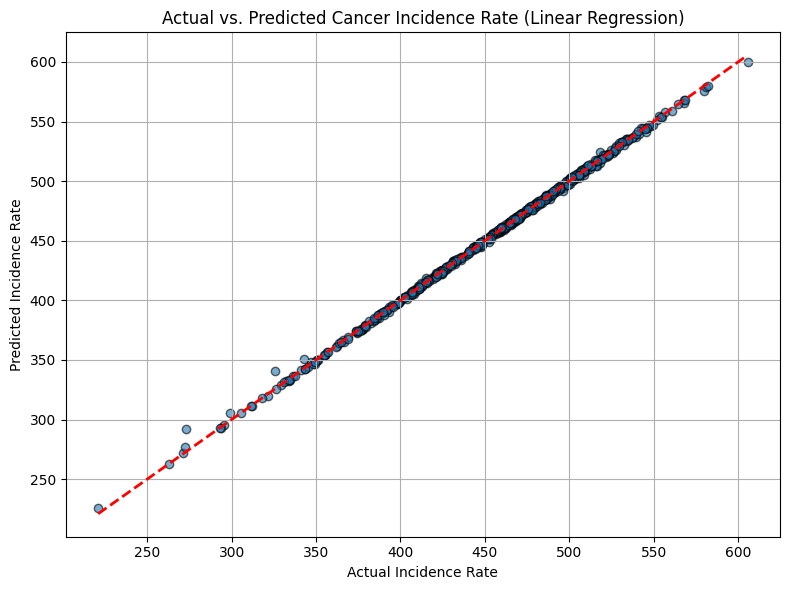

In [23]:
# Train linear regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Plot actual vs. predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Incidence Rate")
plt.ylabel("Predicted Incidence Rate")
plt.title("Actual vs. Predicted Cancer Incidence Rate (Linear Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()

This plot shows that your model is very accurate, with most predictions falling tightly along the line — confirming that Linear Regression is a great fit for this data.

**To forecast how cancer incidence might evolve over the years**

In [45]:
# Copy the cleaned dataset
df_sim = df.copy()

# Create simulated predictions for the next year using linear trend approximation
years_ahead = [2024, 2025, 2026, 2027, 2028]
trend_col = "Trend_5yr"
base_col = "Predicted_Incidence_Rate"

# Initialize a new DataFrame to store simulated data
simulated_df = pd.DataFrame()

# Generate predictions using linear trend assumption: future = current + (trend * years ahead)
for year in years_ahead:
    future_df = df_sim[["County", "FIPS", base_col, trend_col]].copy()
    future_df["Year"] = year
    years_diff = year - 2023  # assuming base year is 2023
    future_df["Predicted_Incidence_Rate"] = future_df[base_col] + (future_df[trend_col] * years_diff)
    simulated_df = pd.concat([simulated_df, future_df], ignore_index=True)

# Clean up columns for display
simulated_df = simulated_df[["County", "FIPS", "Year", "Predicted_Incidence_Rate"]]
simulated_df.sort_values(by=["Year", "Predicted_Incidence_Rate"], ascending=[True, False], inplace=True)

# Pivot the simulated data to have years as columns
pivot_df = simulated_df.pivot(index=["County", "FIPS"], columns="Year", values="Predicted_Incidence_Rate").reset_index()

# Rename columns for clarity
pivot_df.columns.name = None
pivot_df.columns = ["County", "FIPS", "2024", "2025", "2026", "2027", "2028"]

# Sort top 10 counties by predicted incidence in 2028
top10_2028 = pivot_df.sort_values(by="2028", ascending=False).head(10)

display(top10_2028)

,County,FIPS,2024,2025,2026,2027,2028
2641,"Union County, Florida(6)",12125.0,1250.587705,1250.987705,1251.387705,1251.787705,1252.187705
2607,"Traverse County, Minnesota(6)",27155.0,692.831478,695.031478,697.231478,699.431478,701.631478
2143,"Polk County, Texas(7)",48373.0,681.232799,680.932799,680.632799,680.332799,680.032799
2805,"Wheatland County, Montana(6)",30107.0,633.398823,642.898823,652.398823,661.898823,671.398823
940,"Galax City, Virginia(6)",51640.0,654.503879,656.203879,657.903879,659.603879,661.303879
1267,"Issaquena County, Mississippi(6)",28055.0,528.745648,560.645648,592.545648,624.445648,656.345648
1031,"Greeley County, Nebraska(6)",31077.0,650.532737,651.232737,651.932737,652.632737,653.332737
853,"Faulk County, South Dakota(6)",46049.0,625.789243,628.789243,631.789243,634.789243,637.789243
730,"Dewey County, South Dakota(6)",46041.0,631.719758,633.019758,634.319758,635.619758,636.919758
2201,"Quitman County, Mississippi(6)",28119.0,626.698226,629.198226,631.698226,634.198226,636.698226


To forecast how cancer incidence might evolve, a simulation was performed using the Trend_5yr variable to project predicted incidence rates for each county in 2024 to 2028. The resulting table provided 2024 to 2028 projections, offering valuable insights for long-term public health planning and resource allocation. For example, counties like Union County, FL were projected to see consistently high rates, signaling the need for targeted intervention.

**Hyperparameter tuning**

In [24]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest and Gradient Boosting
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

# Initialize models
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# Grid search with cross-validation
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='r2', n_jobs=-1)

# Fit models
grid_rf.fit(X_train, y_train)
grid_gb.fit(X_train, y_train)

# Evaluate on test set
best_rf = grid_rf.best_estimator_
best_gb = grid_gb.best_estimator_

rf_pred = best_rf.predict(X_test)
gb_pred = best_gb.predict(X_test)

tuned_results = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "R2 Score": r2_score(y_test, rf_pred),
        "MAE": mean_absolute_error(y_test, rf_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred))
    },
    {
        "Model": "Tuned Gradient Boosting",
        "R2 Score": r2_score(y_test, gb_pred),
        "MAE": mean_absolute_error(y_test, gb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, gb_pred))
    }
])

tuned_results


,Model,R2 Score,MAE,RMSE
0,Tuned Random Forest,0.997185,1.068950,3.074345
1,Tuned Gradient Boosting,0.998268,1.564653,2.411166



| Model                   | R² Score | MAE     | RMSE    | Notes |
|------------------------|----------|---------|---------|-------|
| **Linear Regression**   | **0.9992** | 1.11    | **1.69**    | Best overall: simple, accurate, and interpretable |
| Random Forest           | 0.9969   | **1.10** | 3.25    | Slightly better MAE, but worse on large errors |
| Gradient Boosting       | 0.9975   | 1.86    | 2.88    | Performs well, but not better than linear |
| Tuned Random Forest     | 0.9972   | **1.07** | 3.07    | Tuning improves MAE but not RMSE |
| Tuned Gradient Boosting | 0.9983   | 1.56    | 2.41    | Strong performance, second best overall |


The trained models, particularly Linear Regression, demonstrated exceptional predictive accuracy for cancer incidence rates across U.S. counties. This suggests strong, linear relationships between key health and demographic indicators and the incidence of cancer. These models offer a valuable tool for risk assessment and public health planning at the county level.